In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

# 1. Menyiapkan Data
data = {
    'outlook': ['sunny', 'sunny', 'Cloudy', 'Rainy', 'Rainy', 'Rainy', 'Cloudy', 'sunny', 'sunny', 'Rainy', 'sunny', 'Cloudy', 'Cloudy', 'Rainy'],
    'temp': ['hot', 'hot', 'hot', 'mild', 'cool', 'cool', 'cool', 'mild', 'cool', 'mild', 'mild', 'mild', 'hot', 'mild'],
    'humidity': ['high', 'high', 'high', 'high', 'normal', 'normal', 'normal', 'high', 'normal', 'normal', 'normal', 'high', 'normal', 'high'],
    'windy': ['no', 'yes', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no', 'no', 'yes', 'yes', 'no', 'yes'],
    'play': ['no', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no']
}
df = pd.DataFrame(data)

# 2. Preprocessing: Mengubah Teks ke Angka
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# X adalah fitur (atribut cuaca), y adalah target (keputusan main)
X = df.drop('play', axis=1)
y = df['play']

# 3. Training Naïve Bayes
model_nb = GaussianNB()
model_nb.fit(X, y)

print("Data Tenis dalam bentuk angka:")
print(df.head())
print("\n--- Model Naïve Bayes Berhasil Dilatih ---")

Data Tenis dalam bentuk angka:
   outlook  temp  humidity  windy  play
0        2     1         0      0     0
1        2     1         0      1     0
2        0     1         0      0     1
3        1     2         0      0     1
4        1     0         1      0     1

--- Model Naïve Bayes Berhasil Dilatih ---


In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Kita gunakan X (fitur) dan y (target) yang sudah dibuat di Latihan 1

# 1. Membuat Model K-NN
# n_neighbors=3 artinya kita meminta model melihat 3 tetangga terdekat
model_knn = KNeighborsClassifier(n_neighbors=3)

# 2. Melatih Model (Training)
model_knn.fit(X, y)

# 3. Melakukan Prediksi pada data yang sama untuk melihat performa [cite: 1]
y_pred_knn = model_knn.predict(X)

print("=== HASIL LATIHAN 2: K-NN ===")
print(f"Akurasi Model: {accuracy_score(y, y_pred_knn) * 100}%")
print("\nLaporan Klasifikasi (Detail Performa):")
# target_names membantu kita membaca hasil: 0 adalah 'No', 1 adalah 'Yes'
print(classification_report(y, y_pred_knn, target_names=['Tidak Main', 'Main']))

=== HASIL LATIHAN 2: K-NN ===
Akurasi Model: 85.71428571428571%

Laporan Klasifikasi (Detail Performa):
              precision    recall  f1-score   support

  Tidak Main       0.75      0.75      0.75         4
        Main       0.90      0.90      0.90        10

    accuracy                           0.86        14
   macro avg       0.82      0.82      0.82        14
weighted avg       0.86      0.86      0.86        14



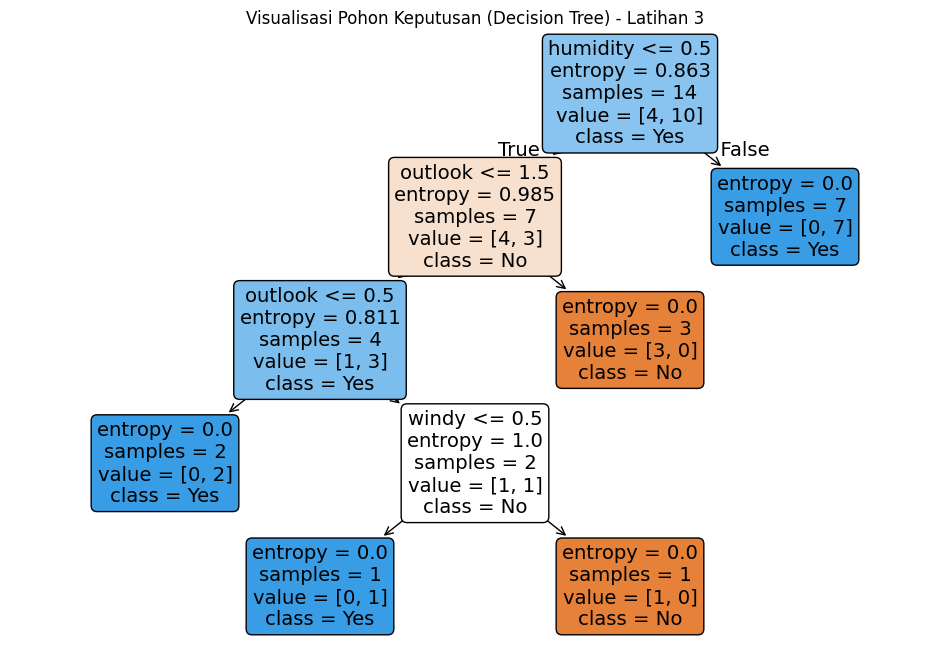

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Membuat Model Decision Tree
# Kita pakai kriteria 'entropy' karena di file Excel dosen kamu pakainya Entropy
model_tree = DecisionTreeClassifier(criterion='entropy')

# 2. Melatih Model
model_tree.fit(X, y)

# 3. Menampilkan Gambar Pohonnya
plt.figure(figsize=(12,8))
plot_tree(model_tree,
          feature_names=['outlook', 'temp', 'humidity', 'windy'],
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True)
plt.title("Visualisasi Pohon Keputusan (Decision Tree) - Latihan 3")
plt.show()

In [4]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

# 1. Data dari file Excel 'Demo Simulasi Kasus ANN'
# X = [Harta, Utang], y = [1: Tidak Bangkrut, 0: Bangkrut]
X_ann = np.array([[1.2, 0.3], [0.8, 0.6], [1.1, 1.0], [0.4, 1.0], [0.5, 1.5]])
y_ann = np.array([1, 1, 1, 0, 0])

# 2. Membuat Arsitektur ANN
model_ann = Sequential()
# Input 2 fitur, 1 Hidden Layer (4 neuron), dan 1 Output Layer
model_ann.add(Dense(4, input_dim=2, activation='relu'))
model_ann.add(Dense(1, activation='sigmoid')) # Sigmoid untuk klasifikasi 0 atau 1

# 3. Compile dan Latih Model
model_ann.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_ann.fit(X_ann, y_ann, epochs=100, verbose=0) # Epochs adalah jumlah iterasi belajar

print("=== HASIL LATIHAN 3: ANN ===")
# Contoh Prediksi: Harta 0.7 dan Utang 0.6 (Kasus di Excel)
prediksi = model_ann.predict(np.array([[0.7, 0.6]]))
print(f"Peluang Kelayakan Pinjaman: {prediksi[0][0]}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== HASIL LATIHAN 3: ANN ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Peluang Kelayakan Pinjaman: 0.5167182683944702
